In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("retail_sales_dataset (1).csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Dataset Overview

The dataset contains retail transaction-level information including
transaction details, customer demographics, product categories, quantity,
price, and total transaction amount.

In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 5 Rows:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Value Check

Missing values can affect calculations and visualizations, so they are
checked before performing further analysis.

In [9]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Duplicate Records

Duplicate records can lead to incorrect sales calculations. Therefore,
duplicate rows are checked before analysis.

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
print("Unique Transaction IDs:", df["Transaction ID"].nunique())
print("Unique Customer IDs:", df["Customer ID"].nunique())

Unique Transaction IDs: 1000
Unique Customer IDs: 1000


Data Cleaning

The dataset was checked for missing values, duplicate records, and incorrect
data types.

The Date column is converted from text format to datetime format so that
monthly and quarterly sales trends can be analyzed correctly.

In [12]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df["Date"].dtype)

datetime64[us]


C:\Users\venne\AppData\Local\Temp\ipykernel_21608\89342408.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)


In [13]:
df["Month"] = df["Date"].dt.to_period("M")
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.to_period("Q")

In [14]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,November,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,February,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,January,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,May,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,May,2023Q2


Descriptive Statistics

Descriptive statistics help summarize the numerical characteristics of the
retail dataset.

The analysis includes Age, Quantity, Price per Unit, and Total Amount.
Mean, median, mode, standard deviation, minimum, and maximum values are
calculated to understand the distribution of these variables.

In [15]:
numeric_columns = ["Age","Quantity","Price per Unit","Total Amount"]

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

statistics.round(2)

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
Age,41.39,42.0,43.0,13.68,18,64
Quantity,2.51,3.0,4.0,1.13,1,4
Price per Unit,179.89,50.0,50.0,189.68,25,500
Total Amount,456.00,135.0,50.0,560.00,25,2000


Customer Demographics Analysis

Customer demographics are analyzed using age groups and gender to understand
the characteristics of the customers contributing to retail sales.

In [16]:
bins = [0, 17, 25, 35, 45, 60, 100]

labels = ["Under 18","18-25","26-35","36-45","46-60", "60+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["Age Group"].value_counts().sort_index()

Age Group
Under 18      0
18-25       169
26-35       205
36-45       202
46-60       331
60+          93
Name: count, dtype: int64

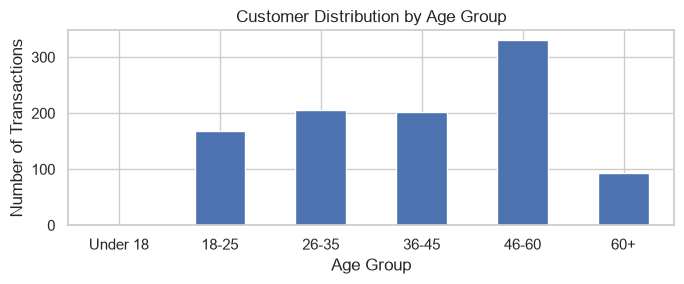

In [17]:
age_group_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(7, 3))

age_group_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation

The 46–60 age group has the highest number of transactions, making it the
largest customer age group in the dataset.

The 60+ group has comparatively fewer transactions. This indicates that
transaction activity varies across customer age groups.

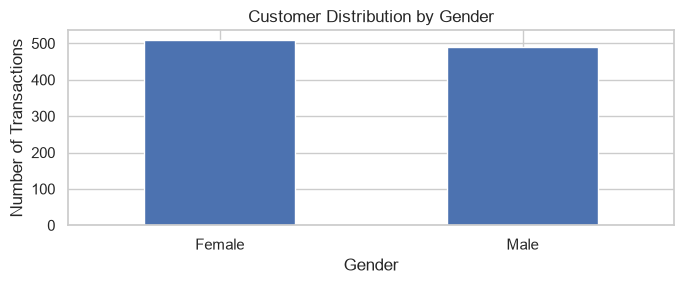

In [18]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 3))

gender_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
gender_revenue = df.groupby("Gender")["Total Amount"].sum()

gender_revenue

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

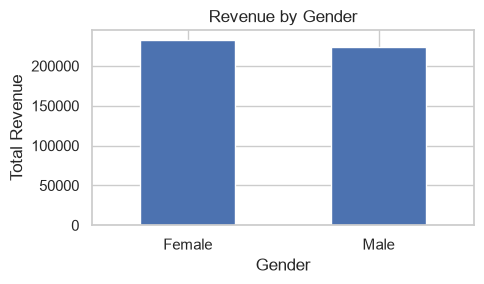

In [20]:
plt.figure(figsize=(5, 3))

gender_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Product Category Analysis

Product category analysis helps identify which categories contribute the most
to sales and transaction volume.

The analysis compares product categories based on:

- Number of transactions
- Quantity sold
- Total revenue
- Average transaction value

In [21]:
category_transactions = df["Product Category"].value_counts()

category_transactions

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

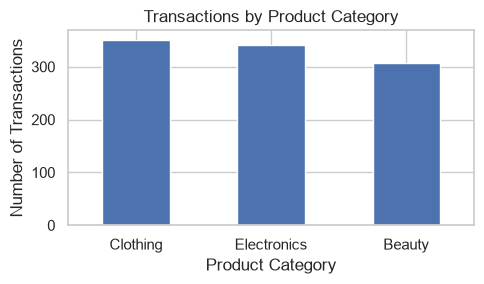

In [22]:
plt.figure(figsize=(5,3))
category_transactions.plot(kind="bar")
plt.title("Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()


Quantity Sold by Category

In [23]:
category_quantity = df.groupby("Product Category")["Quantity"].sum()
category_quantity

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

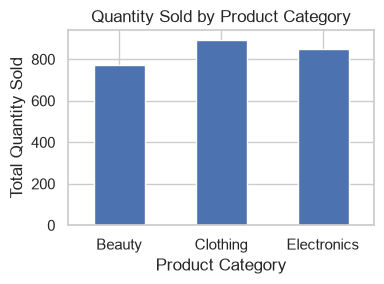

In [24]:
plt.figure(figsize=(4,3))
category_quantity.plot(kind="bar")
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()

In [25]:
category_revenue = df.groupby(
    "Product Category"
)["Total Amount"].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

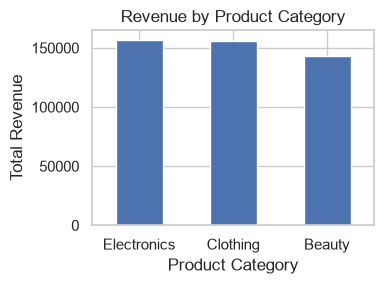

In [26]:
plt.figure(figsize=(4,3))

category_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
category_avg_transaction = df.groupby(
    "Product Category"
)["Total Amount"].mean().sort_values(ascending=False)

category_avg_transaction

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

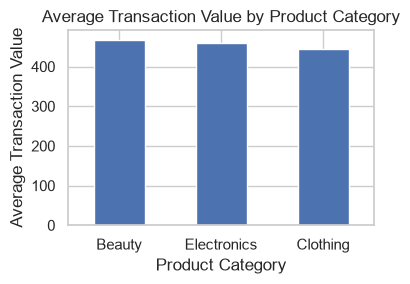

In [28]:
plt.figure(figsize=(4,3))

category_avg_transaction.plot(
    kind="bar"
)

plt.title("Average Transaction Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
category_summary = df.groupby("Product Category").agg(
    Transactions=("Transaction ID", "count"),
    Quantity_Sold=("Quantity", "sum"),
    Total_Revenue=("Total Amount", "sum"),
    Average_Transaction=("Total Amount", "mean")
).sort_values(
    "Total_Revenue",
    ascending=False
)

category_summary.round(2)

,Transactions,Quantity_Sold,Total_Revenue,Average_Transaction
Product Category,,,,
Electronics,342,849,156905,458.79
Clothing,351,894,155580,443.25
Beauty,307,771,143515,467.48


Dataset Limitation — Product-Level Analysis

The dataset contains Product Category but does not contain a Product Name or
Product ID column.

Therefore, a Top 10 Product analysis cannot be performed accurately.

Instead, product performance is analyzed at the Product Category level using
transaction count, quantity sold, total revenue, and average transaction 
value.

Monthly Sales Analysis

Monthly sales analysis helps identify changes in revenue over time and
high-performing or low-performing months.

Revenue is aggregated by month and visualized using a line chart.

In [30]:
monthly_revenue = df.groupby(
    "Month"
)["Total Amount"].sum()

monthly_revenue

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

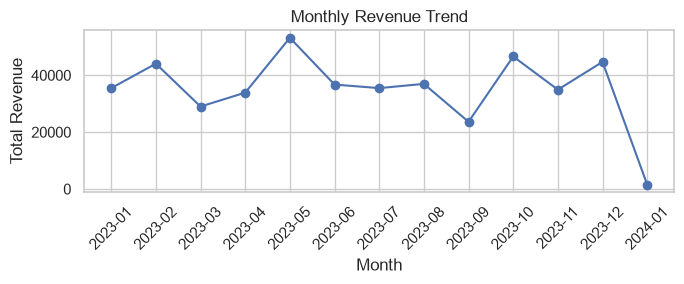

In [31]:
plt.figure(figsize=(7, 3))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
complete_monthly_revenue = monthly_revenue[
    monthly_revenue.index < "2024-01"
]

highest_month = complete_monthly_revenue.idxmax()
highest_revenue = complete_monthly_revenue.max()

lowest_month = complete_monthly_revenue.idxmin()
lowest_revenue = complete_monthly_revenue.min()

print("Highest Revenue Month:", highest_month)
print("Highest Revenue:", f"₹{highest_revenue:,.0f}")

print("\nLowest Complete Month:", lowest_month)
print("Lowest Revenue:", f"₹{lowest_revenue:,.0f}")

Highest Revenue Month: 2023-05
Highest Revenue: ₹53,150

Lowest Complete Month: 2023-09
Lowest Revenue: ₹23,620


Quarterly Sales Analysis

Quarterly revenue analysis provides a broader view of sales performance by
grouping transactions into three-month periods.

This helps identify larger seasonal or business-level changes that may not
be as clear from monthly data.

In [34]:
quarterly_revenue = df.groupby(
    "Quarter"
)["Total Amount"].sum()

quarterly_revenue

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

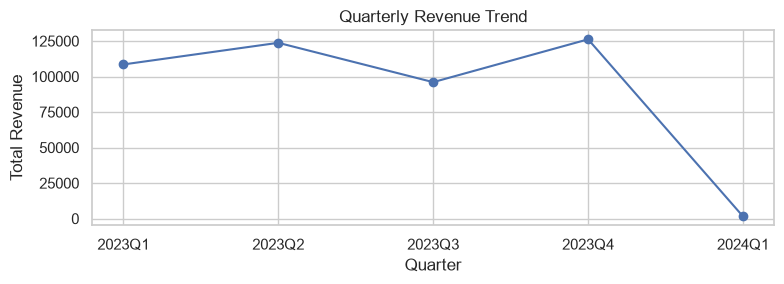

In [35]:
plt.figure(figsize=(8,3))

plt.plot(
    quarterly_revenue.index.astype(str),
    quarterly_revenue.values,
    marker="o"
)

plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
df[df["Date"].dt.to_period("M") == "2024-01"]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Quarter,Age Group
210,211,2024-01-01,CUST211,Male,42,Beauty,3,500,1500,2024-01,January,2024Q1,36-45
649,650,2024-01-01,CUST650,Male,55,Electronics,1,30,30,2024-01,January,2024Q1,46-60


Correlation Analysis

Correlation analysis is used to understand the strength and direction of
linear relationships between numerical variables.

The analysis focuses on Age, Quantity, Price per Unit, and Total Amount.

A correlation value close to +1 indicates a strong positive relationship,
while a value close to -1 indicates a strong negative relationship.
A value close to 0 indicates a weak linear relationship.

In [37]:
numeric_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(3)

,Age,Quantity,Price per Unit,Total Amount
Age,1.000,-0.024,-0.038,-0.061
Quantity,-0.024,1.000,0.018,0.374
Price per Unit,-0.038,0.018,1.000,0.852
Total Amount,-0.061,0.374,0.852,1.000


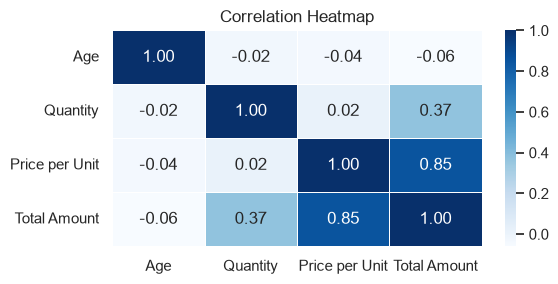

In [38]:
plt.figure(figsize=(6,3))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Additional Analysis — Age vs Transaction Amount

A scatter plot is used to investigate whether customer age has any visible
relationship with transaction amount.

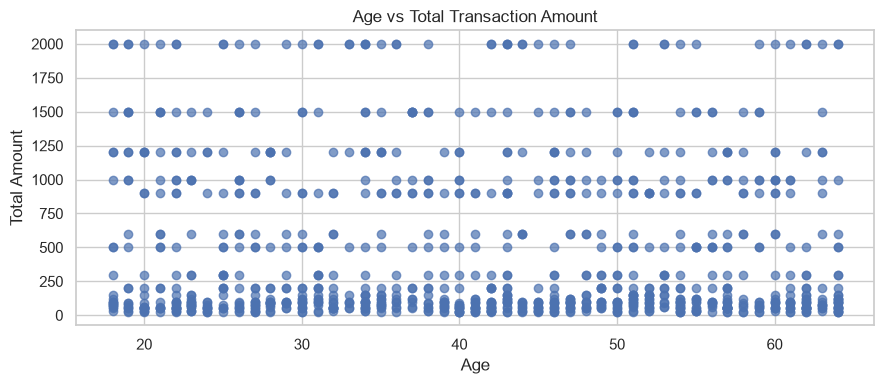

In [39]:
plt.figure(figsize=(9,4))

plt.scatter(
    df["Age"],
    df["Total Amount"],
    alpha=0.7
)

plt.title("Age vs Total Transaction Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

Revenue by Gender and Product Category

This analysis compares revenue across product categories for male and female
customers.

It can help identify differences in purchasing patterns across customer
segments.

In [40]:
gender_category_revenue = pd.pivot_table(
    df,
    values="Total Amount",
    index="Product Category",
    columns="Gender",
    aggfunc="sum"
)

gender_category_revenue

Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


<Figure size 600x300 with 0 Axes>

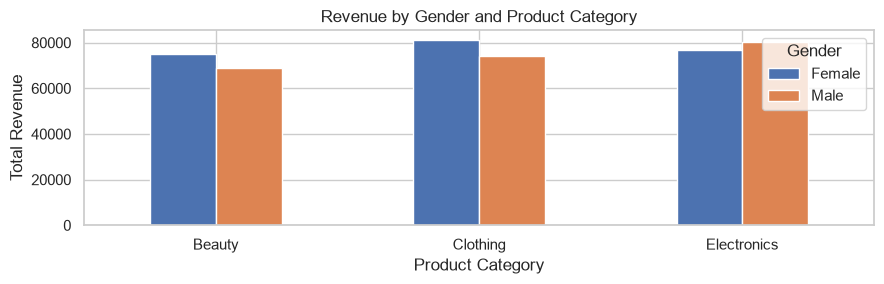

In [41]:
plt.figure(figsize=(6,3))

gender_category_revenue.plot(
    kind="bar",
    figsize=(9, 3)
)

plt.title("Revenue by Gender and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

# Key Insights
  - Total revenue was ₹456,000 from 1,000 transactions.
  - Electronics generated the highest revenue at ₹156,905.
  - Clothing had the highest number of transactions and quantity sold.
  - Beauty had the highest average transaction value.
  - The 46–60 age group contributed the highest revenue.
  - May 2023 had the highest monthly revenue at ₹53,150.
  - Price per Unit and Total Amount had a strong positive correlation of 0.852.
  - Age and Total Amount had a very weak relationship. 

# Data Limitations

- The dataset does not contain Product Name or Product ID, so Top 10 Product analysis is not possible.
- Each Customer ID appears only once, so repeat customer analysis cannot be performed.
- January 2024 contains only two transactions, so it is a partial period.
- Correlation shows relationships between variables but does not prove causation.
- The dataset contains limited customer information such as age and gender.

# Business Recommendations

1. Focus on Electronics because it generated the highest revenue.
2. Investigate the reasons for monthly sales fluctuations.
3. Use customer demographics to plan targeted marketing campaigns.
4. Monitor pricing and transaction value to improve revenue performance.
5. Analyze the 46–60 age group and test suitable offers for this segment.

# Final Conclusion

This project analyzed 1,000 retail transactions to understand sales,
customers, and product categories.

Electronics generated the highest revenue, while Clothing had the highest
number of transactions. The 46–60 age group contributed the highest revenue.

Sales varied across different months, and Price per Unit had a strong
relationship with Total Amount.

Overall, the analysis provides useful insights that can help the business
understand sales performance, customer behavior, and product category
performance.